## Lots of Plots 

In [2]:
from pathlib import Path
import re
import geopandas as gpd

import matplotlib.pyplot as plt
import pandas as pd
import pypsa

try:
    import pycountry
except Exception:
    pycountry = None

# Set the preferred network path; fallback discovery is automatic.
network_path = Path("data/de_result.nc")
n = pypsa.Network(network_path)

country_bus_idx = n.buses.index

bus_country_summary = None
if "country" in n.buses.columns:
    bus_country_summary = (
        n.buses["country"].dropna().astype(str).str.upper().value_counts().head(3).to_dict()
    )

print(f"Loaded network: {network_path}")
print(f"Snapshots: {len(n.snapshots)}")
print(f"Buses: {len(n.buses)} | Lines: {len(n.lines)} | Links: {len(n.links)}")
if bus_country_summary is not None:
    print(f"Top bus country labels: {bus_country_summary}")


Index(['1013 PHS', '10168 hydro', '10258 PHS', '1041 hydro', '10550 PHS',
       '10553 PHS', '10571 hydro', '10592 PHS', '10592 hydro', '10610 hydro',
       ...
       '9687 hydro', '9738 hydro', '9743 hydro', '9748 hydro', '9754 hydro',
       '9758 hydro', '9761 hydro', '9778 hydro', '9783 hydro', '9861 hydro'],
      dtype='object', name='name', length=396)
INFO:pypsa.io:Imported network de_result.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


Loaded network: data/de_result.nc
Snapshots: 1460
Buses: 339 | Lines: 0 | Links: 547
Top bus country labels: {'CN': 339}


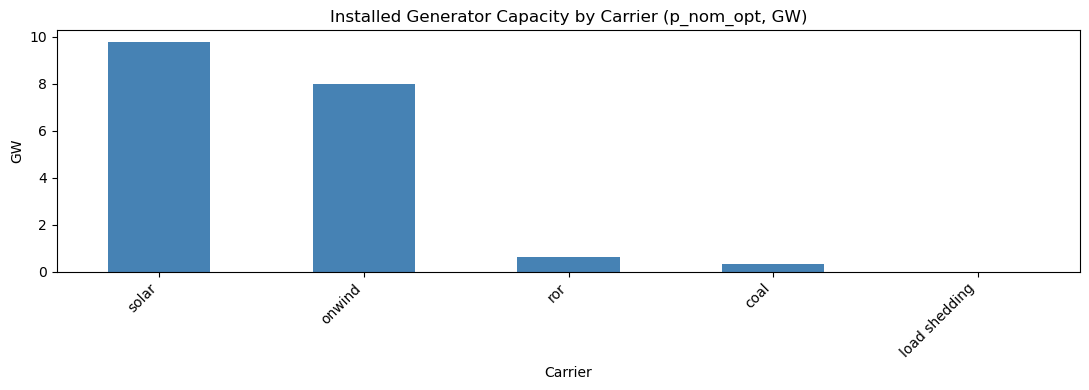

In [3]:
cap_col = "p_nom_opt" if "p_nom_opt" in n.generators.columns else "p_nom"
cap_by_carrier = (
    n.generators.groupby("carrier")[cap_col].sum().sort_values(ascending=False)
    / 1e3
)

fig, ax = plt.subplots(figsize=(11, 4))
cap_by_carrier.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title(f"Installed Generator Capacity by Carrier ({cap_col}, GW)")
ax.set_ylabel("GW")
ax.set_xlabel("Carrier")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

### Voronoi Subdivision Of Bus Regions
This reproduces the Voronoi partition approach used in the project code to split each country into nearest-bus service regions.

Voronoi cells are calculated from solved bus coordinates
Panel 1 raw buses: 19755
Panel 3 solved buses / unique coords (CN): 339/113


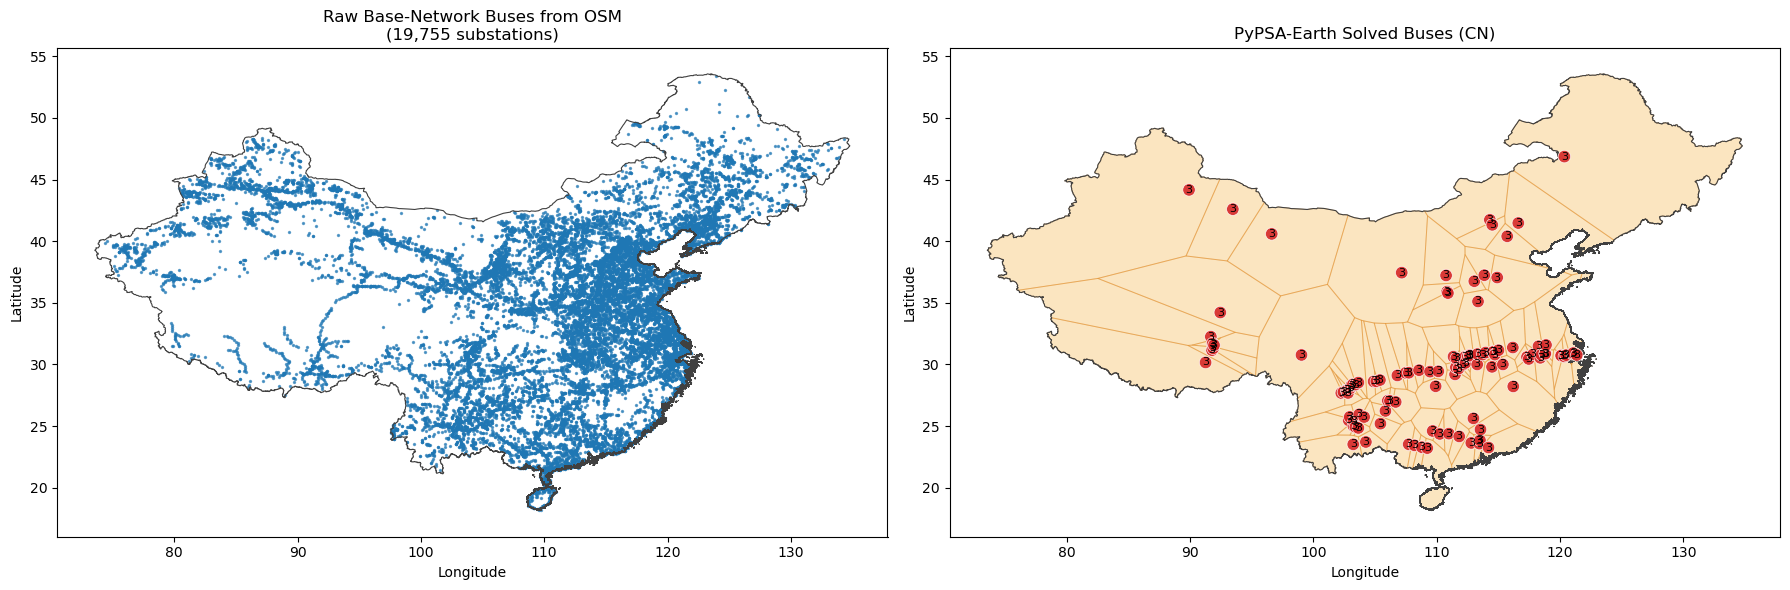

In [14]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pypsa
from scipy.spatial import Voronoi
from shapely.geometry import MultiPoint, Polygon

print("====================================================")
print("Voronoi cells are calculated from solved bus coordinates")
print("====================================================")

# 1) Pre-solve raw buses from base_network outputs
raw_buses = gpd.read_file("../saved/US_test/all_buses_build_network.geojson")
raw_buses = raw_buses[raw_buses.geometry.notna()]

# 3) Final solved network buses (reuse the network loaded in Cell 2).
if "n" in globals():
    n_final = n
elif "network_path" in globals():
    n_final = pypsa.Network(network_path)
else:
    raise NameError("Run Cell 2 first so network variables are defined.")

if "country_bus_idx" in globals() and len(country_bus_idx) > 0:
    final_buses = n_final.buses.loc[n_final.buses.index.intersection(country_bus_idx)]
else:
    final_buses = n_final.buses

final_buses = final_buses.dropna(subset=["x", "y"]).copy()
final_counts = final_buses.groupby(["x", "y"]).size().rename("count").reset_index()

gadm_path = Path(f"../data/gadm/gadm41_CHN/gadm41_CHN.gpkg")
gdf = gpd.read_file(gadm_path, layer="ADM_ADM_0")
if not gdf.empty:
    gdf = gdf[["geometry"]].dissolve().reset_index(drop=True)

def clipped_voronoi_cells(points, outline=None, multiplier=5):
    points = np.asarray(points)
    if len(points) == 0:
        return []
    if len(points) == 1:
        return [outline] if outline is not None else []

    xmin, ymin = np.amin(points, axis=0)
    xmax, ymax = np.amax(points, axis=0)

    if outline is not None and not outline.is_empty:
        minx_o, miny_o, maxx_o, maxy_o = outline.boundary.bounds
        xmin = min(xmin, minx_o)
        ymin = min(ymin, miny_o)
        xmax = max(xmax, maxx_o)
        ymax = max(ymax, maxy_o)

    xspan = max(xmax - xmin, 1e-6)
    yspan = max(ymax - ymin, 1e-6)

    vor = Voronoi(
        np.vstack(
            (
                points,
                [
                    [xmin - multiplier * xspan, ymin - multiplier * yspan],
                    [xmin - multiplier * xspan, ymax + multiplier * yspan],
                    [xmax + multiplier * xspan, ymin - multiplier * yspan],
                    [xmax + multiplier * xspan, ymax + multiplier * yspan],
                ],
            )
        )
    )

    cells = []
    for i in range(len(points)):
        poly = Polygon(vor.vertices[vor.regions[vor.point_region[i]]])
        if not poly.is_valid:
            poly = poly.buffer(0)
        if outline is not None and not outline.is_empty:
            poly = poly.intersection(outline)
        cells.append(poly)

    return cells

country_outline = gdf.geometry.iloc[0] if not gdf.empty else None
country_geom = country_outline 
vor_cells = clipped_voronoi_cells(final_counts[["x", "y"]].to_numpy(), country_geom)
crs = gdf.crs
voronoi_gdf = gpd.GeoDataFrame({"geometry": vor_cells}, crs=crs)
voronoi_gdf = voronoi_gdf[
    voronoi_gdf.geometry.notna()
    & voronoi_gdf.geometry.is_valid
    & ~voronoi_gdf.geometry.is_empty
]

print(f"Panel 1 raw buses: {len(raw_buses)}")
print(f"Panel 3 solved buses / unique coords (CN): {len(final_buses)}/{len(final_counts)}")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

raw_buses.plot(ax=axes[0], markersize=2, color="tab:blue", alpha=0.65)
axes[0].set_title(
    f"Raw Base-Network Buses from OSM\n({len(raw_buses):,} substations)"
)
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

if not voronoi_gdf.empty:
    voronoi_gdf.plot(
        ax=axes[1],
        facecolor="#f6b64c",
        edgecolor="#d97706",
        alpha=0.35,
        linewidth=0.7,
        zorder=1,
    )

gdf.boundary.plot(ax=axes[0], color="0.25", linewidth=0.8, zorder=2)
gdf.boundary.plot(ax=axes[1], color="0.25", linewidth=0.8, zorder=2)

axes[1].scatter(
    final_counts["x"],
    final_counts["y"],
    s=20 + 35 * np.sqrt(final_counts["count"]),
    color="tab:red",
    alpha=0.9,
    edgecolor="white",
    linewidth=0.5,
    zorder=3,
)
for _, r in final_counts[final_counts["count"] > 1].iterrows():
    axes[1].text(r["x"], r["y"], str(int(r["count"])), fontsize=8, ha="center", va="center")
axes[1].set_title(f"PyPSA-Earth Solved Buses (CN)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

for ax in axes.ravel():
    ax.set_aspect("equal", adjustable="datalim")

plt.tight_layout()

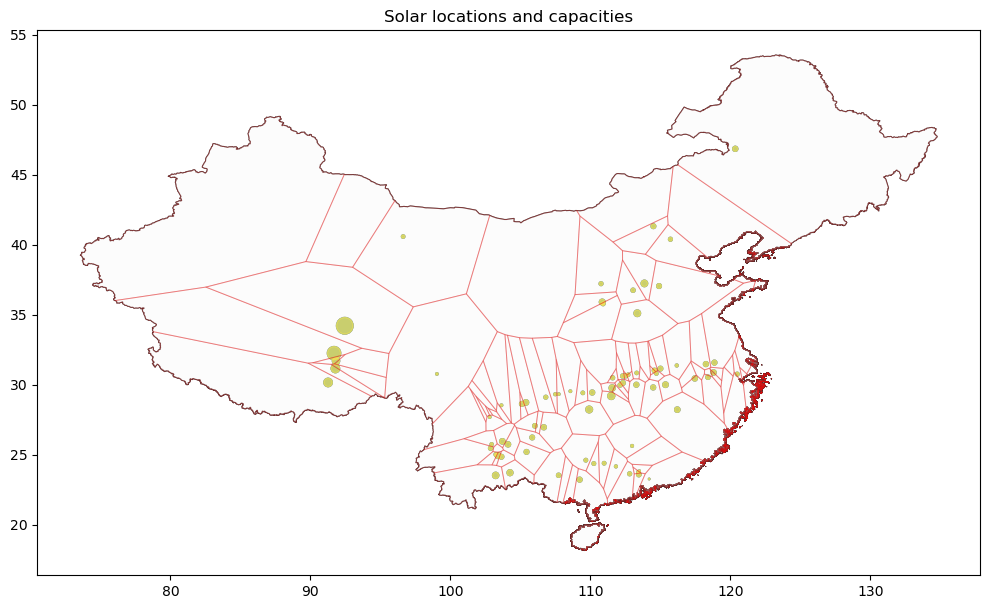

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

gen = n.generators.copy()

# attach bus coordinates
gen["x"] = gen["bus"].map(n.buses["x"])
gen["y"] = gen["bus"].map(n.buses["y"])

gen = gen.dropna(subset=["x", "y"])

carrier_colors = {
    "solar": "gold",
    "onwind": "tab:blue",
    "offwind-ac": "tab:cyan",
    "offwind-dc": "tab:cyan",
    "ror": "tab:green",
    "hydro": "tab:green",
    "nuclear": "tab:red",
    "coal": "black",
    "lignite": "dimgray",
    "CCGT": "tab:orange",
    "OCGT": "tab:brown",
    'load shedding': 'tab:pink'
}

fig, ax = plt.subplots(figsize=(10, 8))

gdf.boundary.plot(
        ax=ax,
        color="0.2",
        linewidth=0.8,
        zorder=1,
    )

for carrier in sorted(gen.carrier.unique()):
    subset = gen[gen.carrier == 'solar'] # --- IGNORE --- subset = gen[gen.carrier == carrier]

    ax.scatter(
        subset["x"],
        subset["y"],
        s=np.sqrt(subset["p_nom"].clip(lower=0)) * 2,
        alpha=0.6,
        color=carrier_colors.get(carrier, "grey"),
        label=f"{carrier} ({len(subset)})",
    )


if not voronoi_gdf.empty:
    voronoi_gdf.plot(
        ax=ax,
        facecolor="#f7f7f7",
        edgecolor="#dd0e0e",
        alpha=0.35,
        linewidth=0.7,
        zorder=1,
    )

ax.set_title("Solar locations and capacities")
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [32]:
import pypsa

n = pypsa.Network("data/de_result.nc")

print(n.buses.country.value_counts().head(20))

Index(['1013 PHS', '10168 hydro', '10258 PHS', '1041 hydro', '10550 PHS',
       '10553 PHS', '10571 hydro', '10592 PHS', '10592 hydro', '10610 hydro',
       ...
       '9687 hydro', '9738 hydro', '9743 hydro', '9748 hydro', '9754 hydro',
       '9758 hydro', '9761 hydro', '9778 hydro', '9783 hydro', '9861 hydro'],
      dtype='object', name='name', length=396)
INFO:pypsa.io:Imported network de_result.nc has buses, carriers, generators, global_constraints, links, loads, storage_units, stores


country
CN    339
Name: count, dtype: int64


Selected buses: 339
Loads selected: 77
Total solar generators: 77
Solar generators after filter: 77

Monthly totals (TWh)
       Demand  Solar
Month               
Jan       0.0    0.0
Feb       0.0    0.0
Mar       0.0    0.0
Apr       0.0    0.0
May       0.0    0.0
Jun       0.0    0.0
Jul       0.0    0.0
Aug       0.0    0.0
Sep       0.0    0.0
Oct       0.0    0.0
Nov       0.0    0.0
Dec       0.0    0.0


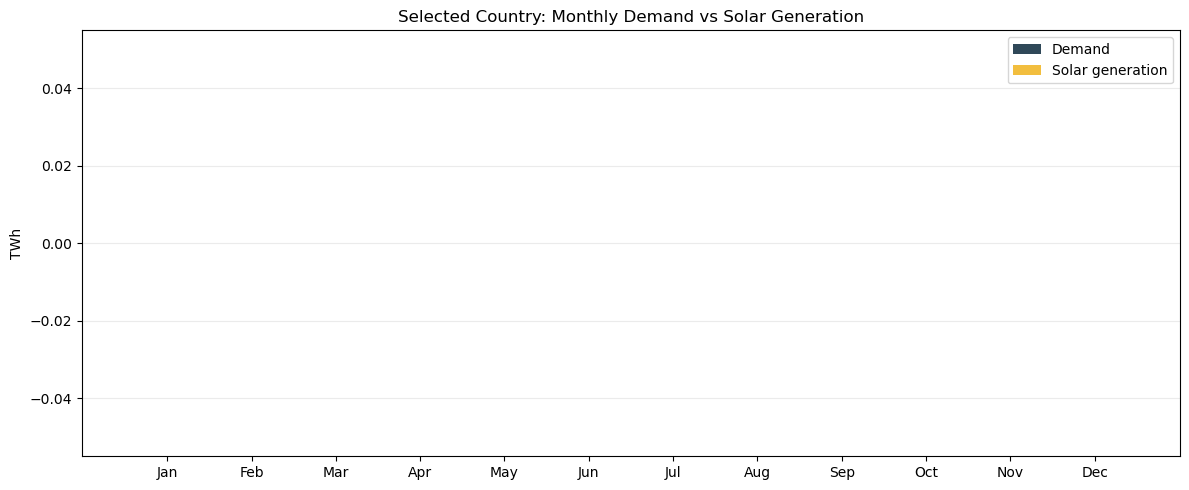

In [29]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

# --------------------------------------------------
# Network
# --------------------------------------------------

if "n_model" in globals():
    n_plot = n_model
elif "n" in globals():
    n_plot = n
elif "network_path" in globals():
    n_plot = pypsa.Network(network_path)
else:
    raise RuntimeError("No network loaded.")

country_label = (
    target_country_name
    if "target_country_name" in globals()
    else "Selected Country"
)

country_iso2 = (
    target_country_iso2
    if "target_country_iso2" in globals()
    else None
)

# --------------------------------------------------
# Bus selection
# --------------------------------------------------

if (
    country_iso2
    and "country" in n_plot.buses.columns
):
    buses = n_plot.buses.index[
        n_plot.buses.country.astype(str)
        .str.upper()
        .eq(country_iso2.upper())
    ]
else:
    buses = n_plot.buses.index

print(f"Selected buses: {len(buses):,}")

# --------------------------------------------------
# Snapshot weights
# --------------------------------------------------

weights = (
    n_plot.snapshot_weightings.generators
    .reindex(n_plot.snapshots)
    .fillna(1.0)
)

# --------------------------------------------------
# DEMAND
# --------------------------------------------------

load_idx = n_plot.loads.index[
    n_plot.loads.bus.isin(buses)
]

print(f"Loads selected: {len(load_idx):,}")

if len(load_idx):

    load_col = (
        "p"
        if hasattr(n_plot.loads_t, "p")
        and not n_plot.loads_t.p.empty
        else "p_set"
    )

    demand_ts = (
        getattr(n_plot.loads_t, load_col)
        .reindex(columns=load_idx, fill_value=0)
        .sum(axis=1)
    )

    demand_month = (
        demand_ts
        .mul(weights)
        .groupby(demand_ts.index.month)
        .sum()
        .reindex(range(1, 13), fill_value=0)
        / 1e6
    )

else:
    demand_month = pd.Series(
        0.0,
        index=range(1, 13),
    )

# --------------------------------------------------
# SOLAR GENERATION
# --------------------------------------------------

solar_generators = n_plot.generators[
    n_plot.generators.carrier.isin(
        ["solar", "solar rooftop"]
    )
]

print(f"Total solar generators: {len(solar_generators):,}")

solar_generators = solar_generators[
    solar_generators.bus.isin(buses)
]

print(
    f"Solar generators after filter: "
    f"{len(solar_generators):,}"
)

if len(solar_generators):

    solar_ts = (
        n_plot.generators_t.p
        .reindex(
            columns=solar_generators.index,
            fill_value=0,
        )
        .sum(axis=1)
    )

    solar_month = (
        solar_ts
        .mul(weights)
        .groupby(solar_ts.index.month)
        .sum()
        .reindex(range(1, 13), fill_value=0)
        / 1e6
    )

else:
    solar_month = pd.Series(
        0.0,
        index=range(1, 13),
    )

# --------------------------------------------------
# DATAFRAME
# --------------------------------------------------

months = pd.Index(
    pd.date_range(
        "2000-01-01",
        periods=12,
        freq="MS",
    ).strftime("%b"),
    name="Month",
)

plot_df = pd.DataFrame(
    {
        "Demand": demand_month.values,
        "Solar": solar_month.values,
    },
    index=months,
)

print("\nMonthly totals (TWh)")
print(plot_df)

# --------------------------------------------------
# PLOT
# --------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 5)
)

x = range(len(plot_df))

width = 0.42

ax.bar(
    [i - width/2 for i in x],
    plot_df["Demand"],
    width=width,
    label="Demand",
    color="#2f4858",
)

ax.bar(
    [i + width/2 for i in x],
    plot_df["Solar"],
    width=width,
    label="Solar generation",
    color="#f2be3e",
)

ax.set_xticks(list(x))
ax.set_xticklabels(plot_df.index)

ax.set_ylabel("TWh")
ax.set_title(
    f"{country_label}: Monthly Demand vs Solar Generation"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend()

plt.tight_layout()
plt.show()

Nodes plotted: 113
Annual solar generation allocated: 0.00 TWh


,node_label,x,y,bus_count,allocation_share,allocated_twh
0,N1,102.2621,27.6868,3,0.0088,0.0
1,N2,112.6993,30.7171,3,0.0088,0.0
2,N3,116.2073,28.2218,3,0.0088,0.0
3,N4,116.1697,31.3784,3,0.0088,0.0
4,N5,115.7179,40.3967,3,0.0088,0.0
...,...,...,...,...,...,...
108,N109,108.5689,29.5392,3,0.0088,0.0
109,N110,108.1985,23.4457,3,0.0088,0.0
110,N111,107.7393,29.3312,3,0.0088,0.0
111,N112,107.7281,23.5317,3,0.0088,0.0


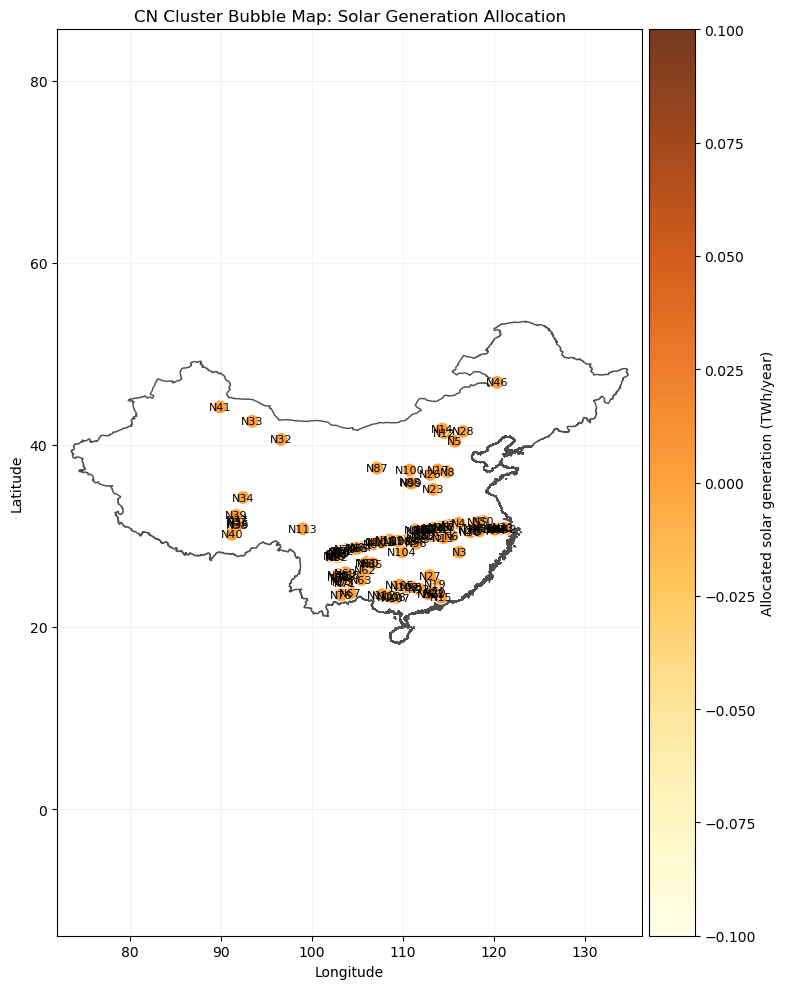

In [20]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import pypsa
from shapely.geometry import MultiPoint

# 1) Load solved network (prefer already-loaded object).
if "n_model" in globals():
    n_map = n
elif "n" in globals():
    n_map = n
else:
    def _find_solved_nc(root=Path("../saved"), preferred_year="2018"):
        files = sorted(root.glob("*/*.nc"))
        if not files:
            raise FileNotFoundError(f"No solved .nc found under {root.resolve()}")
        preferred = [p for p in files if preferred_year in p.parts]
        return preferred[0] if preferred else files[-1]

    n_map = pypsa.Network(_find_solved_nc(preferred_year="2018"))

country_label = "CN"

# 2) Build country node table (cluster nodes represented by unique solved bus coordinates).
if "country_bus_idx" in globals() and len(country_bus_idx) > 0:
    country_buses = n_map.buses.loc[n_map.buses.index.intersection(country_bus_idx)]
else:
    country_buses = n_map.buses

country_buses = country_buses.dropna(subset=["x", "y"]).copy()
if country_buses.empty:
    raise ValueError("No buses with coordinates found for the selected country.")

country_buses["node_key"] = country_buses["x"].round(5).astype(str) + "|" + country_buses["y"].round(5).astype(str)
nodes = country_buses.groupby("node_key", as_index=False).agg(
    x=("x", "first"),
    y=("y", "first"),
    bus_count=("x", "size"),
)

# 3) Compute annual node metric from the selected network.
weights = n_map.snapshot_weightings.generators.reindex(n_map.snapshots).fillna(1.0)

solar_carriers = ["solar", "solar rooftop"]
solar_idx = n_map.generators.index[
    n_map.generators.bus.isin(country_buses.index) & n_map.generators.carrier.isin(solar_carriers)
]

if len(solar_idx) > 0:
    metric_label = "solar generation"
    metric_col = "metric_twh"
    gen_energy = n_map.generators_t.p.reindex(columns=solar_idx, fill_value=0.0).mul(weights, axis=0) / 1e6
    gen_bus = n_map.generators.loc[solar_idx, "bus"]
    metric_by_bus = gen_energy.T.groupby(gen_bus).sum().sum(axis=1)
else:
    all_idx = n_map.generators.index[n_map.generators.bus.isin(country_buses.index)]
    metric_label = "total generation"
    metric_col = "metric_twh"
    if len(all_idx) > 0:
        gen_energy = n_map.generators_t.p.reindex(columns=all_idx, fill_value=0.0).mul(weights, axis=0) / 1e6
        gen_bus = n_map.generators.loc[all_idx, "bus"]
        metric_by_bus = gen_energy.T.groupby(gen_bus).sum().sum(axis=1)
    else:
        metric_by_bus = pd.Series(dtype=float)

bus_to_node = country_buses["node_key"]
metric_by_node = metric_by_bus.groupby(bus_to_node.reindex(metric_by_bus.index)).sum() if not metric_by_bus.empty else pd.Series(dtype=float)

nodes = nodes.set_index("node_key")
nodes[metric_col] = metric_by_node.reindex(nodes.index).fillna(0.0)

total_metric_twh = float(nodes[metric_col].sum())
if total_metric_twh > 0:
    nodes["allocation_share"] = nodes[metric_col] / total_metric_twh
else:
    nodes["allocation_share"] = 1.0 / len(nodes)

nodes["allocated_twh"] = nodes["allocation_share"] * total_metric_twh
nodes = nodes.reset_index().sort_values("allocated_twh", ascending=False).reset_index(drop=True)
nodes["node_label"] = [f"N{i+1}" for i in range(len(nodes))]

fig, ax = plt.subplots(figsize=(8, 10))
gdf.boundary.plot(ax=ax, color="0.3", linewidth=1.0, zorder=1)

size_scale = 1800
sizes = 100 + size_scale * nodes["allocated_twh"] / max(nodes["allocated_twh"].max(), 1e-9)
sc = ax.scatter(
    nodes["x"],
    nodes["y"],
    s=sizes,
    c=nodes["allocated_twh"],
    cmap="YlOrBr",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    zorder=3,
)

for _, row in nodes.iterrows():
    ax.text(row["x"], row["y"], row["node_label"], fontsize=8, ha="center", va="center", zorder=4)

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label(f"Allocated {metric_label} (TWh/year)")

ax.set_title(f"{country_label} Cluster Bubble Map: {metric_label.title()} Allocation")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.15)
ax.set_aspect("equal", adjustable="datalim")
plt.tight_layout()

print(f"Nodes plotted: {len(nodes)}")
print(f"Annual {metric_label} allocated: {total_metric_twh:.2f} TWh")
display(nodes[["node_label", "x", "y", "bus_count", "allocation_share", "allocated_twh"]].round(4))

Plotting window: 2023-01-01 00:00:00  ->  2023-01-14 18:00:00  (56 snapshots)


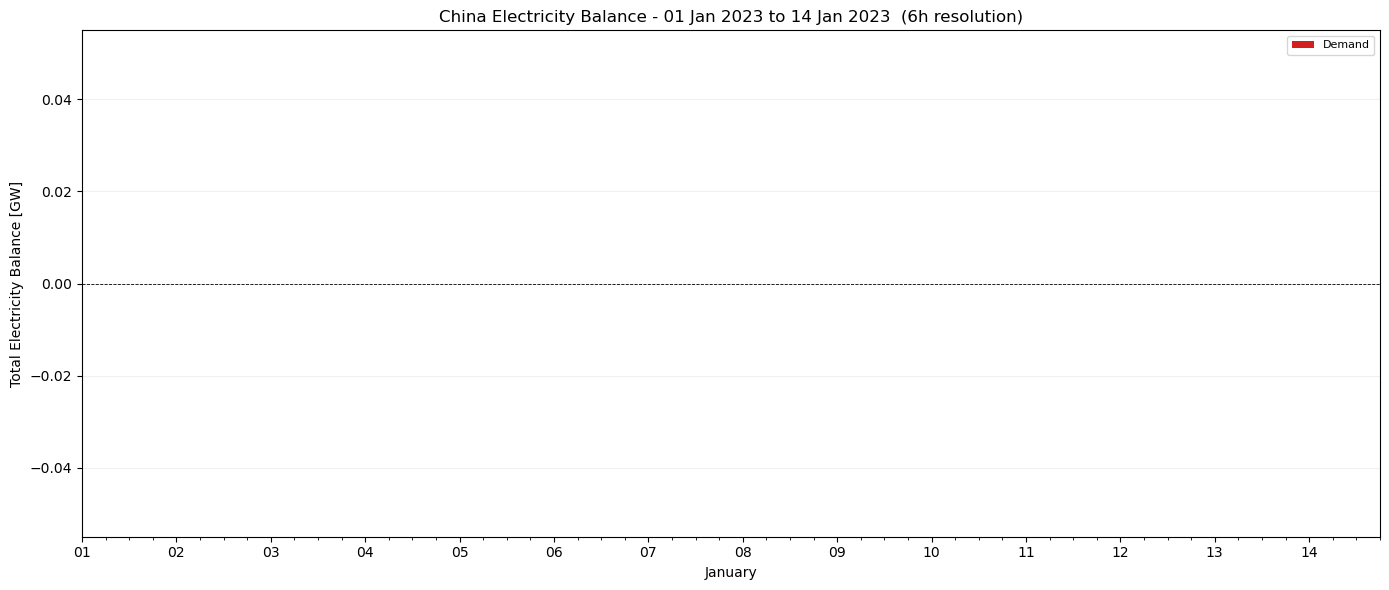

Snapshot resolution: 6h | snapshots in window: 56
Peak generation: 0.0 GW
Peak demand:     0.0 GW


In [ ]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa

# ------------------------------------------------------------------
# Load network (reuse n_model / n_map if already in scope)
# ------------------------------------------------------------------
if "n_model" in globals():
    _n = n_model
elif "n_map" in globals():
    _n = n_map
elif "n" in globals():
    _n = n
else:
    def _find_nc(root=Path("../saved"), yr="2018"):
        files = sorted(root.glob("*/*.nc"))
        if not files:
            raise FileNotFoundError(f"No .nc files under {root.resolve()}")
        pref = [p for p in files if yr in p.parts]
        return pref[0] if pref else files[-1]
    _n = pypsa.Network(_find_nc())

country_label = target_country_name if "target_country_name" in globals() else "Selected Country"

if "country_bus_idx" in globals() and len(country_bus_idx) > 0:
    country_bus_idx_plot = _n.buses.index.intersection(country_bus_idx)
elif "target_country_iso2" in globals() and "country" in _n.buses.columns and target_country_iso2:
    country_bus_idx_plot = _n.buses.index[_n.buses["country"].astype(str).str.upper().eq(target_country_iso2)]
else:
    country_bus_idx_plot = _n.buses.index

if len(country_bus_idx_plot) == 0:
    raise ValueError("No buses found for selected country in this network.")

# ------------------------------------------------------------------
# Pick a 7-day window — change start_date to explore other periods
# ------------------------------------------------------------------
start_date = "2018-01-01"
end_date = "2018-01-08"

snaps = _n.snapshots
window = snaps[(snaps >= start_date) & (snaps < end_date)]
if len(window) == 0:
    # fall back to first 7 days of whatever year is present
    window = snaps[: min(56, len(snaps))]
print(f"Plotting window: {window[0]}  ->  {window[-1]}  ({len(window)} snapshots)")

# ------------------------------------------------------------------
# Carrier -> display-name + colour (extend as needed)
# ------------------------------------------------------------------
CARRIER_STYLE = {
    "CCGT": ("CCGT", "#8B0000"),
    "OCGT": ("OCGT", "#F4A9A8"),
    "onwind": ("Onshore wind", "#4c78a8"),
    "offwind-ac": ("Offshore wind", "#6aafd4"),
    "offwind-dc": ("Offshore wind", "#6aafd4"),
    "solar": ("Solar PV", "#f2be3e"),
    "nuclear": ("Nuclear", "#9c755f"),
    "hydro": ("Hydro", "#54a24b"),
    "ror": ("Hydro", "#54a24b"),
    "biomass": ("Biomass", "#72b7b2"),
    "coal": ("Coal", "#4d4d4d"),
    "lignite": ("Coal", "#4d4d4d"),
    "oil": ("Oil", "#b279a2"),
    "geothermal": ("Geothermal", "#e8825c"),
    "battery": ("Li-Ion battery", "#e040fb"),
    "H2": ("Hydrogen", "#aacc44"),
}


def _label_color(carrier):
    style = CARRIER_STYLE.get(carrier)
    if style:
        return style
    return (carrier, "#bab0ab")


# ------------------------------------------------------------------
# Generator dispatch [GW], positive
# ------------------------------------------------------------------
country_gens = _n.generators.index[_n.generators.bus.isin(country_bus_idx_plot)]
gen_p = _n.generators_t.p.reindex(columns=country_gens, fill_value=0.0).loc[window]
gen_carrier = _n.generators.loc[country_gens, "carrier"]

# collapse to display-name groups
pos_contrib = {}
for carrier, grp in gen_carrier.groupby(gen_carrier):
    label, color = _label_color(carrier)
    series = gen_p[grp.index].sum(axis=1) / 1e3  # MW -> GW
    if series.abs().max() < 1e-6:
        continue
    if label in pos_contrib:
        pos_contrib[label] = (pos_contrib[label][0] + series, color)
    else:
        pos_contrib[label] = (series, color)

# ------------------------------------------------------------------
# Storage units (positive = dispatch above zero, negative = charging below zero)
# ------------------------------------------------------------------
neg_storage = {}
if not _n.storage_units.empty:
    country_su = _n.storage_units.index[_n.storage_units.bus.isin(country_bus_idx_plot)]
    if len(country_su):
        su_p = _n.storage_units_t.p.reindex(columns=country_su, fill_value=0.0).loc[window]
        su_carrier = _n.storage_units.loc[country_su, "carrier"]
        for carrier, grp in su_carrier.groupby(su_carrier):
            label, color = _label_color(carrier)
            series = su_p[grp.index].sum(axis=1) / 1e3
            dispatch = series.clip(lower=0)
            charging = series.clip(upper=0)
            if dispatch.abs().max() > 1e-6:
                if label in pos_contrib:
                    pos_contrib[label] = (pos_contrib[label][0] + dispatch, color)
                else:
                    pos_contrib[label] = (dispatch, color)
            if charging.abs().max() > 1e-6:
                neg_storage[label] = (charging, color)

# ------------------------------------------------------------------
# Stores (battery, H2 — p > 0 = withdrawing from store = generation)
# ------------------------------------------------------------------
if not _n.stores.empty:
    country_st = _n.stores.index[_n.stores.bus.isin(country_bus_idx_plot)]
    if len(country_st):
        st_p = _n.stores_t.p.reindex(columns=country_st, fill_value=0.0).loc[window]
        st_carrier = _n.stores.loc[country_st, "carrier"]
        for carrier, grp in st_carrier.groupby(st_carrier):
            label, color = _label_color(carrier)
            series = st_p[grp.index].sum(axis=1) / 1e3
            dispatch = series.clip(lower=0)
            charging = series.clip(upper=0)
            if dispatch.abs().max() > 1e-6:
                if label in pos_contrib:
                    pos_contrib[label] = (pos_contrib[label][0] + dispatch, color)
                else:
                    pos_contrib[label] = (dispatch, color)
            if charging.abs().max() > 1e-6:
                neg_storage[label] = (charging, color)

# ------------------------------------------------------------------
# Demand [GW], negative
# ------------------------------------------------------------------
country_loads = _n.loads.index[_n.loads.bus.isin(country_bus_idx_plot)]
load_col = "p" if "p" in _n.loads_t and not _n.loads_t.p.empty else "p_set"
load_df = getattr(_n.loads_t, load_col).reindex(columns=country_loads, fill_value=0.0).loc[window]
demand_gw = load_df.sum(axis=1) / 1e3

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 6))
t = window.to_pydatetime()

# --- positive stack (generation + storage dispatch) ---
ordered_pos = sorted(pos_contrib.items(), key=lambda x: -x[1][0].mean())
pos_labels = [k for k, _ in ordered_pos]
pos_arrays = [v[0].values for _, v in ordered_pos]
pos_colors = [v[1] for _, v in ordered_pos]

if pos_arrays:
    ax.stackplot(t, pos_arrays, labels=pos_labels, colors=pos_colors, alpha=0.88)

# --- negative stack (demand + storage charging) ---
neg_items = [("Demand", (-demand_gw, "#CC0000"))] + list(neg_storage.items())
neg_labels = [k for k, _ in neg_items]
neg_arrays = [v[0].values for _, v in neg_items]
neg_colors = [v[1] for _, v in neg_items]

if neg_arrays:
    ax.stackplot(t, neg_arrays, labels=neg_labels, colors=neg_colors, alpha=0.88)

ax.axhline(0, color="black", linewidth=0.6, linestyle="--", zorder=5)

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d"))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[6, 12, 18]))

month_name = pd.Timestamp(window[0]).strftime("%B")
ax.set_xlabel(month_name)
ax.set_ylabel("Total Electricity Balance [GW]")
ax.set_title(
    f"{country_label} Electricity Balance - {window[0].strftime('%d %b %Y')} to {window[-1].strftime('%d %b %Y')}"
    f"  ({int((window[1]-window[0]).total_seconds()//3600)}h resolution)"
)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="upper right", ncol=2, fontsize=8, framealpha=0.8)

ax.grid(axis="y", alpha=0.18)
ax.set_xlim(t[0], t[-1])
plt.tight_layout()
plt.show()

res_h = int((window[1] - window[0]).total_seconds() // 3600)
print(f"Snapshot resolution: {res_h}h | snapshots in window: {len(window)}")
print(f"Peak generation: {sum(a.max() for a in pos_arrays):.1f} GW")
print(f"Peak demand:     {demand_gw.max():.1f} GW")